<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula04b_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

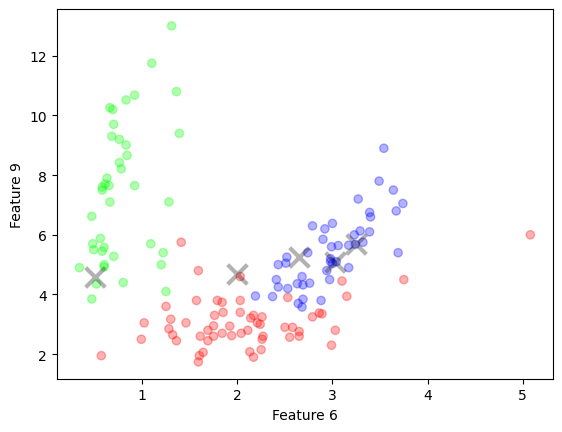

In [24]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

X, y = load_wine(return_X_y=True)
feats = [6,9]
X_reduced = X[:, feats]
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

from matplotlib import pyplot as plt

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="brg", alpha=0.3)
plt.scatter(X_test[:5, 0], X_test[:5, 1], c='k', marker='x', s=200, linewidths=3, alpha=0.3)
plt.xlabel(f"Feature {feats[0]}")
plt.ylabel(f"Feature {feats[1]}")
plt.show()

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model = KNeighborsClassifier(n_neighbors=15)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.9722222222222222


In [65]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
import numpy as np
from scipy import stats

class KNN(BaseEstimator, ClassifierMixin):
  def __init__(self, n_neighbors=5):
    self.n_neighbors = n_neighbors

  def fit(self, X, y):
    self.X_train = X
    self.y_train = y
    return self

  def pitagoras(self, x):
    return np.sqrt(np.sum((self.X_train - x)**2, axis=1))

  def predict(self, X):
    y_pred = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
      distances = self.pitagoras(X[i])
      idx = np.argsort(distances)[:self.n_neighbors]
      y_pred[i], _ = stats.mode(self.y_train[idx])
    return y_pred

model = KNN(n_neighbors=13)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.9722222222222222
